In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv("Telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
print("Missing Values:\n",df.isnull().sum())
print("\nData Types:\n",df.dtypes)

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod     

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nMissing values in TotalCharges:", df['TotalCharges'].isnull().sum())

TotalCharges dtype: float64

Missing values in TotalCharges: 11


In [6]:
df = df.dropna()
print("Rows after dropping missing values:", df.shape[0])

Rows after dropping missing values: 7032


In [7]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64


In [8]:
churn_counts = df['Churn'].value_counts()
churn_rate = round(df['Churn'].value_counts(normalize=True)*100, 2)
print("Churn Counts:\n", churn_counts)
print("\nChurn Rate %:\n",churn_rate)

Churn Counts:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate %:
 Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


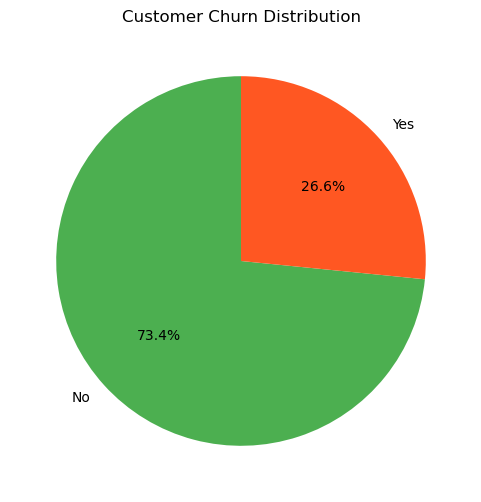

In [9]:
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['No', 'Yes'], autopct='%1.1f%%',
       colors=['#4CAF50', '#FF5722'], startangle=90)
plt.title('Customer Churn Distribution')
plt.show()

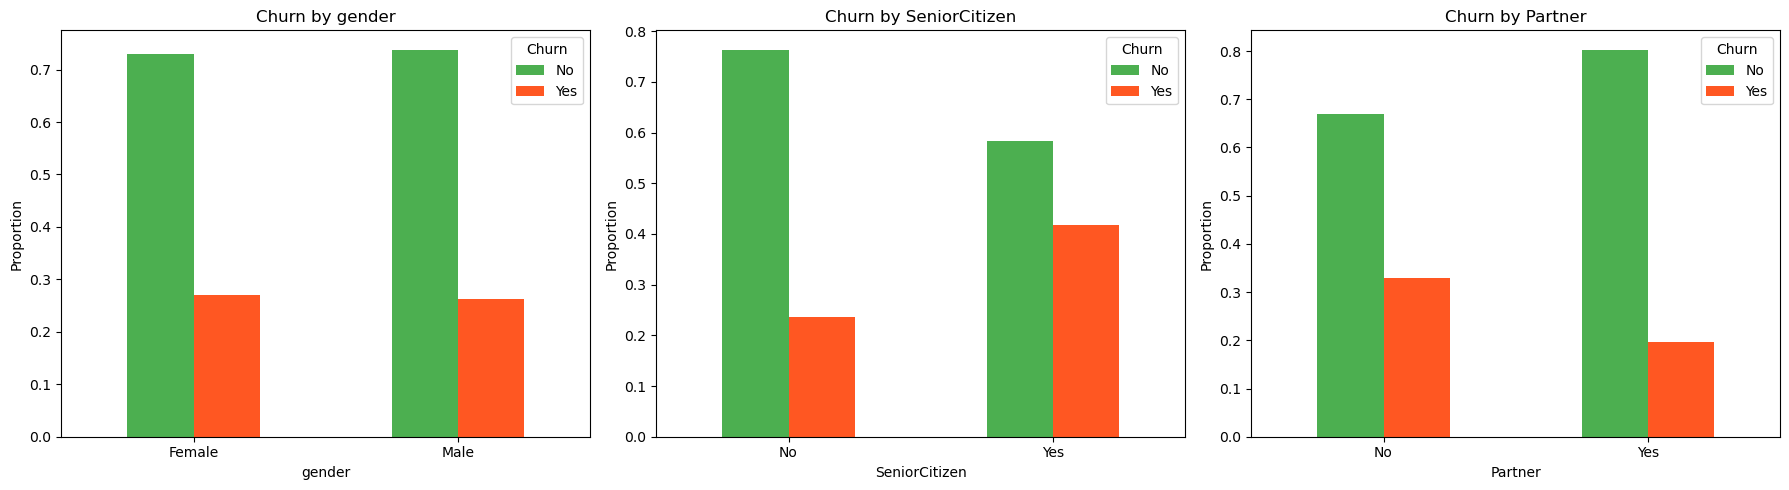

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['gender', 'SeniorCitizen', 'Partner']):
    df.groupby(col)['Churn'].value_counts(normalize=True).unstack().plot(
        kind='bar', ax=axes[i], color=['#4CAF50','#FF5722'])
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print(contract_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487


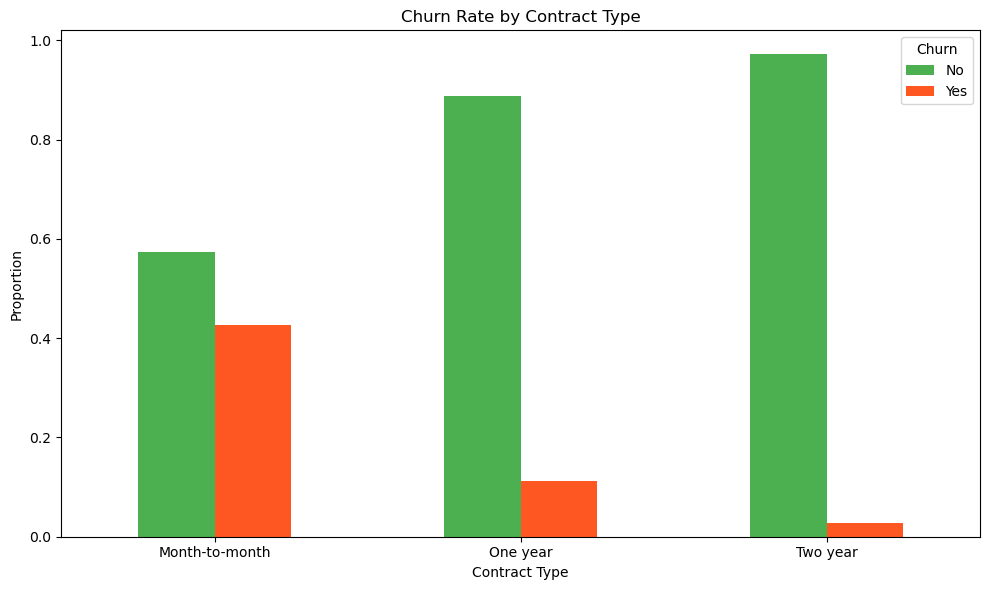

In [12]:
contract_churn.plot(kind='bar', figsize=(10,6), color=['#4CAF50','#FF5722'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

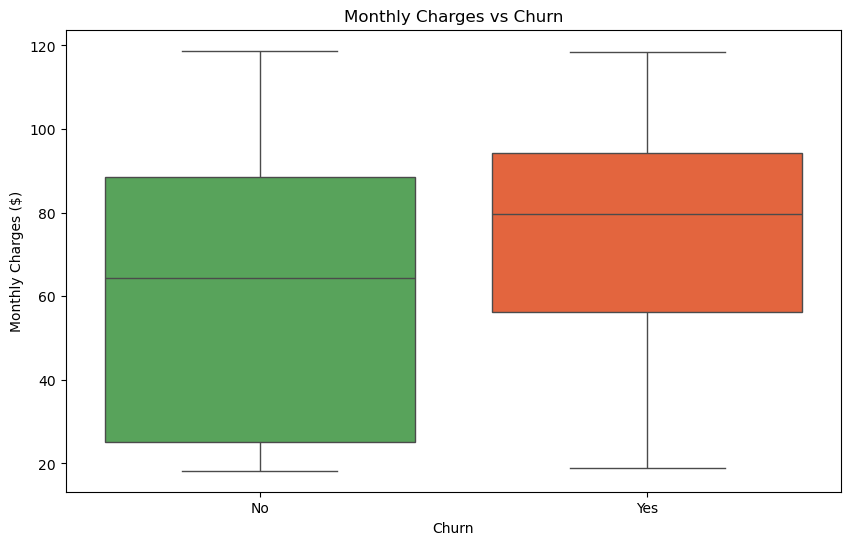

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, 
            hue='Churn', palette=['#4CAF50','#FF5722'], legend=False)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

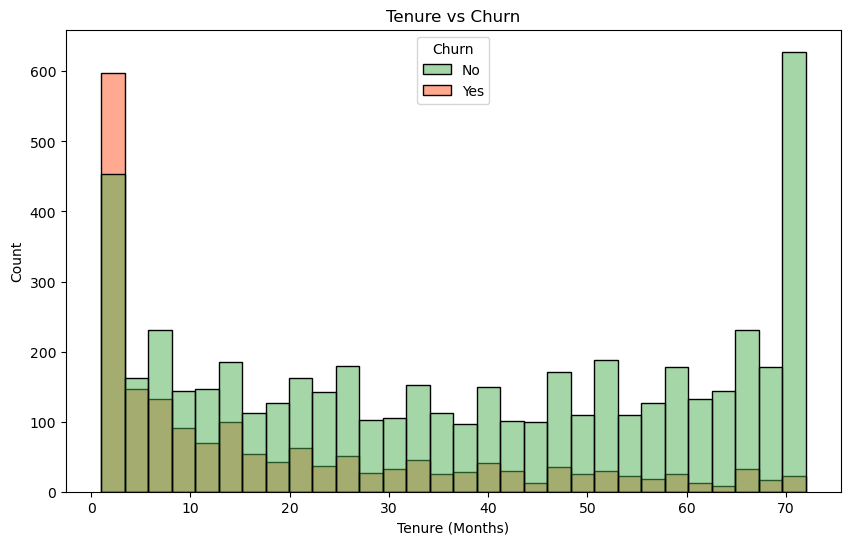

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='tenure', hue='Churn', 
             palette=['#4CAF50','#FF5722'], bins=30)
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

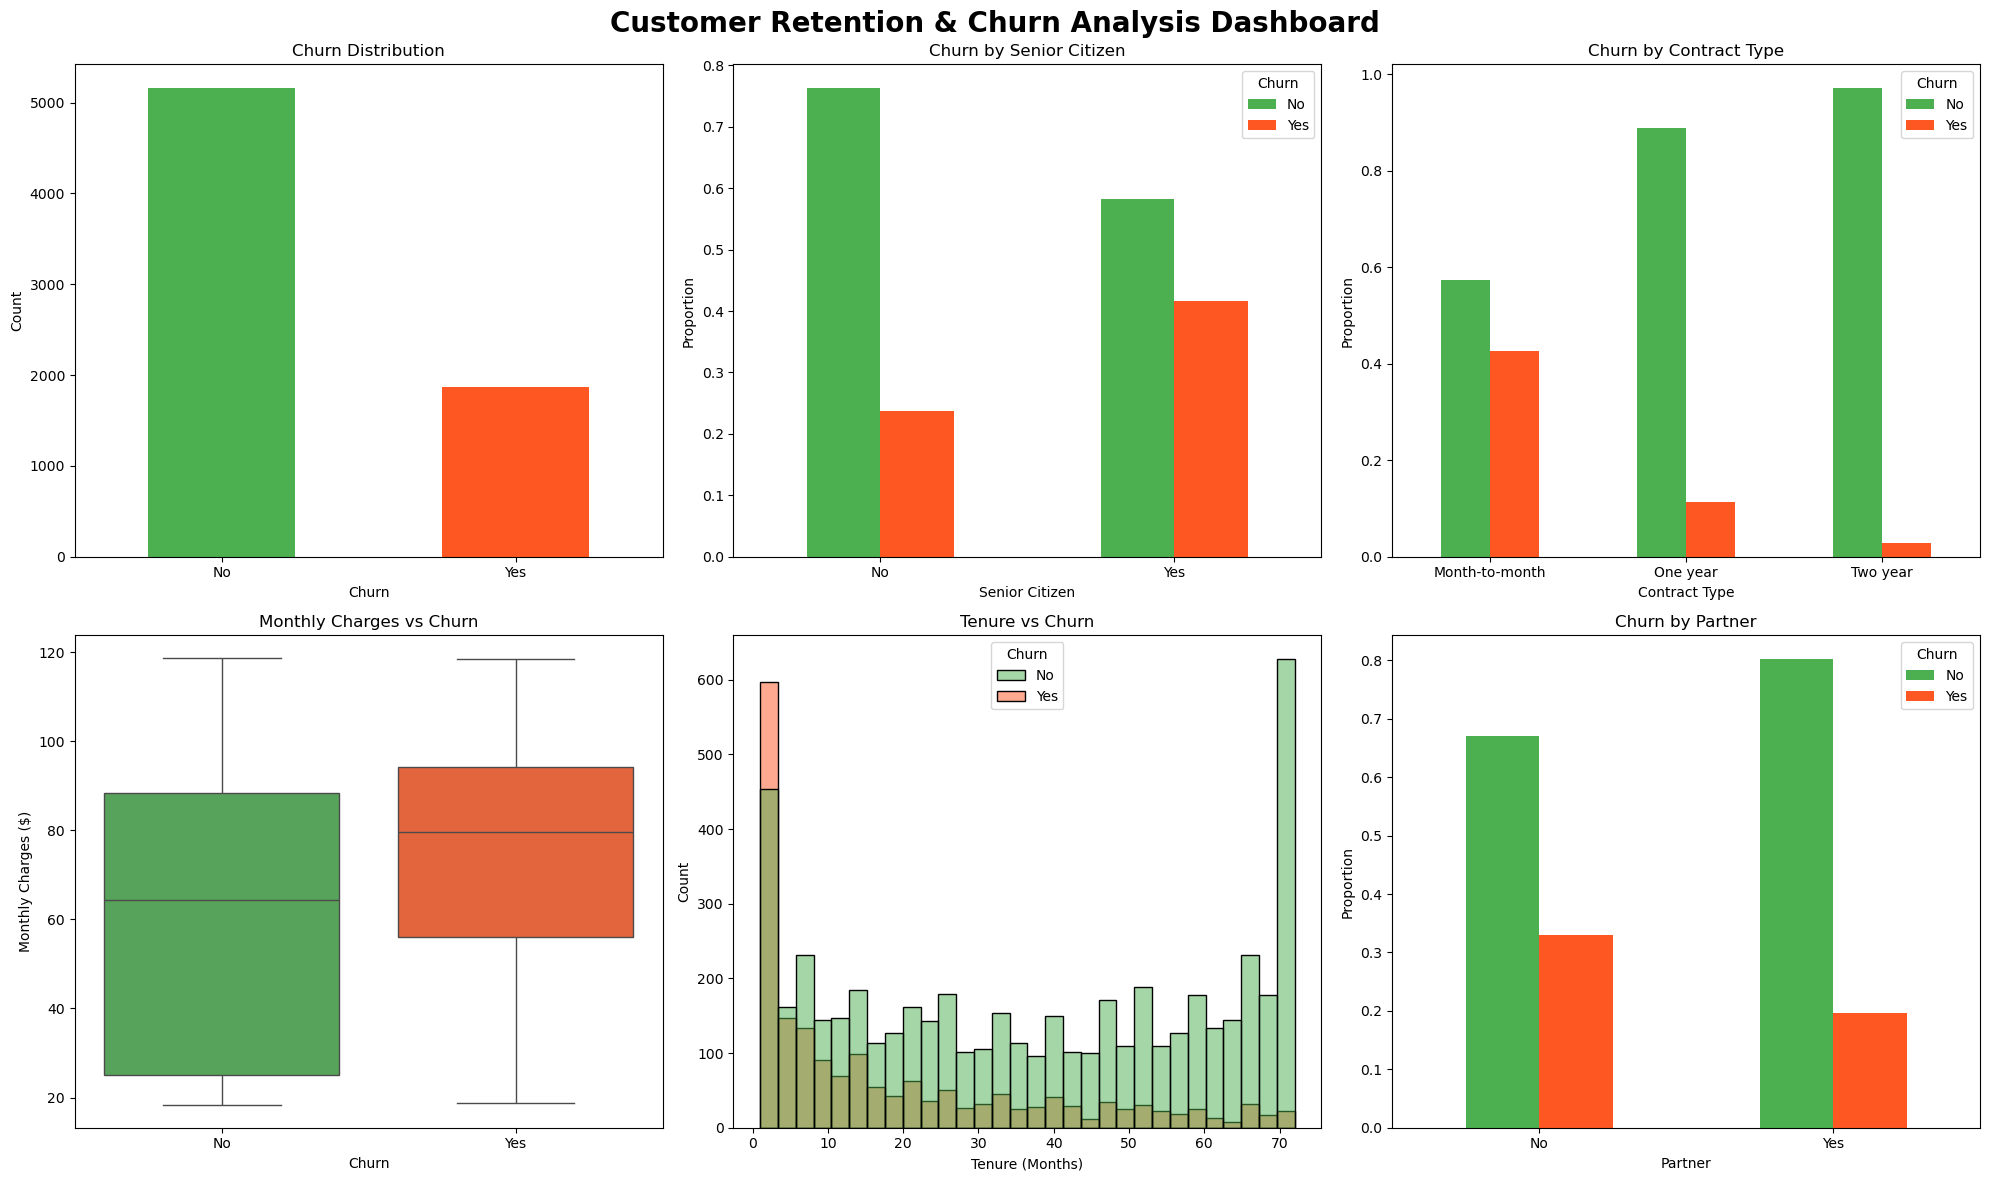

In [16]:
plt.close('all')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Customer Retention & Churn Analysis Dashboard', 
             fontsize=20, fontweight='bold')

# Chart 1 - Churn Distribution
churn_counts.plot(kind='bar', ax=axes[0,0], color=['#4CAF50','#FF5722'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2 - Churn by Senior Citizen
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,1], color=['#4CAF50','#FF5722'])
axes[0,1].set_title('Churn by Senior Citizen')
axes[0,1].set_xlabel('Senior Citizen')
axes[0,1].set_ylabel('Proportion')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3 - Churn by Contract
contract_churn.plot(kind='bar', ax=axes[0,2], color=['#4CAF50','#FF5722'])
axes[0,2].set_title('Churn by Contract Type')
axes[0,2].set_xlabel('Contract Type')
axes[0,2].set_ylabel('Proportion')
axes[0,2].tick_params(axis='x', rotation=0)

# Chart 4 - Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            hue='Churn', palette=['#4CAF50','#FF5722'], 
            legend=False, ax=axes[1,0])
axes[1,0].set_title('Monthly Charges vs Churn')
axes[1,0].set_xlabel('Churn')
axes[1,0].set_ylabel('Monthly Charges ($)')

# Chart 5 - Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn',
             palette=['#4CAF50','#FF5722'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Tenure vs Churn')
axes[1,1].set_xlabel('Tenure (Months)')
axes[1,1].set_ylabel('Count')

# Chart 6 - Churn by Partner
df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[1,2], color=['#4CAF50','#FF5722'])
axes[1,2].set_title('Churn by Partner')
axes[1,2].set_xlabel('Partner')
axes[1,2].set_ylabel('Proportion')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('Churn_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## 📊 Key Insights & Recommendations

### 🔍 Overall Churn Rate
- Overall churn rate is 26.58% — significantly higher than industry standard of 5-7%
- 1 in every 4 customers is leaving the business!

### 👥 Customer Segments
- Senior citizens churn more than non-senior citizens
- Customers without partners are more likely to churn

### 📋 Contract Type
- Month-to-month customers churn at 42.7% — 15x more than 2 year contract customers!
- Recommendation: Offer discounts to encourage longer contract commitments!

### 💰 Monthly Charges
- Churned customers were paying higher monthly charges
- Recommendation: Review pricing strategy for high-value plans!

### 🕐 Tenure
- New customers churn most in first few months
- Recommendation: Create special retention offers for first 6 months!

### ✅ Final Recommendation
- Focus retention efforts on month-to-month contract customers
- Offer loyalty discounts to new customers in first 6 months
- Review pricing for high monthly charge customers!